In [1]:
# ==========================================
# Multiview 3D Reconstruction - Voxel Version
# Synthetic dataset + deep learning + visualization
# ==========================================

import os
import cv2
import math
import random
import shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

try:
    from skimage import measure
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [2]:

# ==========================================
# 1) Utility functions
# ==========================================

def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def set_axes_equal(ax):
    """Make 3D plot axes have equal scale."""
    limits = np.array([
        ax.get_xlim3d(),
        ax.get_ylim3d(),
        ax.get_zlim3d()
    ])
    spans = limits[:, 1] - limits[:, 0]
    centers = np.mean(limits, axis=1)
    radius = 0.5 * max(spans)
    ax.set_xlim3d([centers[0] - radius, centers[0] + radius])
    ax.set_ylim3d([centers[1] - radius, centers[1] + radius])
    ax.set_zlim3d([centers[2] - radius, centers[2] + radius])

def get_shape_color(shape_type):
    colors = {
        "sphere": "royalblue",
        "cube": "seagreen",
        "cylinder": "darkorange",
        "cone": "purple",
        "torus": "hotpink",
    }
    return colors.get(shape_type, "gray")


In [3]:

# ==========================================
# 2) Voxel generation
# ==========================================

def voxelize_shape(shape_type, resolution=32):
    """
    Create a binary voxel grid for a simple synthetic object.
    Output shape: [resolution, resolution, resolution], values in {0,1}
    Coordinate system is normalized to [-1, 1].
    """
    coords = np.linspace(-1, 1, resolution)
    X, Y, Z = np.meshgrid(coords, coords, coords, indexing="ij")
    grid = np.zeros((resolution, resolution, resolution), dtype=np.float32)

    if shape_type == "sphere":
        grid[(X**2 + Y**2 + Z**2) <= 0.65**2] = 1.0

    elif shape_type == "cube":
        grid[(np.abs(X) <= 0.65) & (np.abs(Y) <= 0.65) & (np.abs(Z) <= 0.65)] = 1.0

    elif shape_type == "cylinder":
        grid[((X**2 + Y**2) <= 0.45**2) & (np.abs(Z) <= 0.8)] = 1.0

    elif shape_type == "cone":
        # Cone with base at z=-1 and tip at z=1
        z01 = (Z + 1) / 2.0  # [0,1]
        radius = 0.75 * (1.0 - z01) + 0.05
        grid[((X**2 + Y**2) <= radius**2) & (Z >= -1) & (Z <= 1)] = 1.0

    elif shape_type == "torus":
        R, r = 0.55, 0.22
        grid[(((np.sqrt(X**2 + Y**2) - R) ** 2 + Z**2) <= r**2)] = 1.0

    else:
        raise ValueError(f"Unknown shape_type: {shape_type}")

    return grid


In [4]:

# ==========================================
# 3) Synthetic multiview dataset creation
# ==========================================

def render_shape_to_image(shape_type, view_id, num_views, out_path, dpi=80):
    """
    Render a simple 3D shape from a specific azimuth angle and save as PNG.
    """
    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111, projection="3d")
    color = get_shape_color(shape_type)

    if shape_type == "sphere":
        u = np.linspace(0, 2 * np.pi, 30)
        v = np.linspace(0, np.pi, 30)
        u, v = np.meshgrid(u, v)
        x = np.sin(v) * np.cos(u)
        y = np.sin(v) * np.sin(u)
        z = np.cos(v)
        ax.plot_surface(x, y, z, color=color, alpha=0.85, linewidth=0)

    elif shape_type == "cube":
        vertices = np.array([
            [-1,-1,-1], [ 1,-1,-1], [ 1,-1, 1], [-1,-1, 1],
            [-1, 1,-1], [ 1, 1,-1], [ 1, 1, 1], [-1, 1, 1]
        ])
        faces = [
            [vertices[j] for j in [0,1,2,3]],
            [vertices[j] for j in [4,5,6,7]],
            [vertices[j] for j in [0,1,5,4]],
            [vertices[j] for j in [2,3,7,6]],
            [vertices[j] for j in [0,3,7,4]],
            [vertices[j] for j in [1,2,6,5]],
        ]
        ax.add_collection3d(Poly3DCollection(faces, alpha=0.9, facecolor=color, edgecolor="black"))

    elif shape_type == "cylinder":
        z = np.linspace(-1, 1, 30)
        theta = np.linspace(0, 2 * np.pi, 30)
        theta, z = np.meshgrid(theta, z)
        x = 0.75 * np.cos(theta)
        y = 0.75 * np.sin(theta)
        ax.plot_surface(x, y, z, color=color, alpha=0.85, linewidth=0)

    elif shape_type == "cone":
        z = np.linspace(-1, 1, 30)
        theta = np.linspace(0, 2 * np.pi, 30)
        theta, z = np.meshgrid(theta, z)
        radius = 0.75 * (1 - (z + 1) / 2.0) + 0.05
        x = radius * np.cos(theta)
        y = radius * np.sin(theta)
        ax.plot_surface(x, y, z, color=color, alpha=0.85, linewidth=0)

    elif shape_type == "torus":
        R, r = 0.6, 0.23
        u = np.linspace(0, 2 * np.pi, 40)
        v = np.linspace(0, 2 * np.pi, 25)
        u, v = np.meshgrid(u, v)
        x = (R + r * np.cos(v)) * np.cos(u)
        y = (R + r * np.cos(v)) * np.sin(u)
        z = r * np.sin(v)
        ax.plot_surface(x, y, z, color=color, alpha=0.85, linewidth=0)

    ax.view_init(elev=20, azim=(360.0 * view_id / num_views))
    ax.set_xlim([-1.4, 1.4])
    ax.set_ylim([-1.4, 1.4])
    ax.set_zlim([-1.4, 1.4])
    ax.axis("off")
    set_axes_equal(ax)

    plt.savefig(out_path, dpi=dpi, bbox_inches="tight", pad_inches=0.0)
    plt.close(fig)

def create_synthetic_multiview_dataset(
    root="./synthetic_data",
    num_objects=20,
    num_views=8,
    voxel_resolution=32,
    overwrite=True
):
    """
    Creates:
      synthetic_data/
        sphere_000/
          view_000.png ... view_007.png
          voxel.npy
        cube_001/
          ...
    """
    root = Path(root)

    if overwrite and root.exists():
        shutil.rmtree(root)

    root.mkdir(parents=True, exist_ok=True)

    shapes = ["sphere", "cube", "cylinder", "cone", "torus"]

    for obj_id in range(num_objects):
        shape_type = shapes[obj_id % len(shapes)]
        obj_dir = root / f"{shape_type}_{obj_id:03d}"
        obj_dir.mkdir(parents=True, exist_ok=True)

        # Save voxel ground truth
        voxel = voxelize_shape(shape_type, resolution=voxel_resolution)
        np.save(obj_dir / "voxel.npy", voxel)

        # Save multiview images
        for view_id in range(num_views):
            img_path = obj_dir / f"view_{view_id:03d}.png"
            render_shape_to_image(shape_type, view_id, num_views, img_path)

        print(f"Created {obj_dir.name}")

    print(f"\n✅ Dataset created at: {root.resolve()}")
    return root


In [5]:

# ==========================================
# 4) Dataset class
# ==========================================

class SyntheticMultiViewDataset(Dataset):
    def __init__(self, data_dir, num_views=8, image_size=128):
        self.data_dir = Path(data_dir)
        self.num_views = num_views
        self.image_size = image_size
        self.objects = sorted([d for d in self.data_dir.iterdir() if d.is_dir()])

    def __len__(self):
        return len(self.objects)

    def __getitem__(self, idx):
        obj_dir = self.objects[idx]
        views = []

        for view_id in range(self.num_views):
            img_path = obj_dir / f"view_{view_id:03d}.png"
            img = cv2.imread(str(img_path))
            if img is None:
                raise FileNotFoundError(f"Missing image: {img_path}")

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.image_size, self.image_size))
            img = img.astype(np.float32) / 255.0
            img = img.transpose(2, 0, 1)  # HWC -> CHW
            views.append(img)

        views = np.stack(views, axis=0)  # [V, 3, H, W]

        voxel = np.load(obj_dir / "voxel.npy").astype(np.float32)  # [D, D, D]
        voxel = voxel[None, ...]  # [1, D, D, D]

        return {
            "views": torch.tensor(views, dtype=torch.float32),
            "voxel": torch.tensor(voxel, dtype=torch.float32),
            "name": obj_dir.name
        }


In [6]:

# ==========================================
# 5) Model
# ==========================================

class MultiViewEncoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.AdaptiveAvgPool2d(1)
        )

        self.attention = nn.Sequential(
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.fc = nn.Sequential(
            nn.Linear(512, latent_dim),
            nn.BatchNorm1d(latent_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, views):
        """
        views: [B, V, 3, H, W]
        returns latent: [B, latent_dim]
        """
        B, V, C, H, W = views.shape
        feats = []

        for i in range(V):
            feat = self.cnn(views[:, i]).view(B, -1)  # [B, 512]
            feats.append(feat)

        feats = torch.stack(feats, dim=1)  # [B, V, 512]
        weights = F.softmax(self.attention(feats), dim=1)  # [B, V, 1]
        pooled = (feats * weights).sum(dim=1)  # [B, 512]
        return self.fc(pooled)

class VoxelDecoder(nn.Module):
    def __init__(self, latent_dim=256, base_channels=128):
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 4 * 4 * 4 * base_channels),
            nn.ReLU(inplace=True)
        )

        self.deconv = nn.Sequential(
            nn.ConvTranspose3d(base_channels, 64, kernel_size=4, stride=2, padding=1),   # 8^3
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose3d(64, 32, kernel_size=4, stride=2, padding=1),             # 16^3
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),

            nn.ConvTranspose3d(32, 16, kernel_size=4, stride=2, padding=1),              # 32^3
            nn.BatchNorm3d(16),
            nn.ReLU(inplace=True),

            nn.Conv3d(16, 1, kernel_size=1)  # final logits
        )

        self.base_channels = base_channels

    def forward(self, latent):
        x = self.fc(latent)
        x = x.view(-1, self.base_channels, 4, 4, 4)
        x = self.deconv(x)
        return x  # logits: [B, 1, 32, 32, 32]

class MultiViewVoxelReconstructor(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.encoder = MultiViewEncoder(latent_dim=latent_dim)
        self.decoder = VoxelDecoder(latent_dim=latent_dim)

    def forward(self, views):
        latent = self.encoder(views)
        vox_logits = self.decoder(latent)
        return vox_logits


In [7]:

# ==========================================
# 6) Training
# ==========================================

def train_model(model, dataloader, epochs=100, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=4, factor=0.5)

    losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for batch in dataloader:
            views = batch["views"].to(device)   # [B, V, 3, H, W]
            target_voxel = batch["voxel"].to(device)  # [B, 1, D, D, D]

            pred_logits = model(views)
            loss = criterion(pred_logits, target_voxel)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / max(1, len(dataloader))
        losses.append(avg_loss)
        scheduler.step(avg_loss)
        if epoch % 10 == 0:
            print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {avg_loss:.4f}")

    plt.figure(figsize=(8, 4))
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid(True)
    plt.show()

    return model, losses


In [8]:

# ==========================================
# 7) Visualization helpers
# ==========================================

def show_input_views(sample, max_views=8):
    views = sample["views"].numpy()  # [V, 3, H, W]
    V = min(max_views, views.shape[0])

    fig, axes = plt.subplots(1, V, figsize=(3 * V, 3))
    if V == 1:
        axes = [axes]

    for i in range(V):
        img = views[i].transpose(1, 2, 0)
        axes[i].imshow(img)
        axes[i].set_title(f"View {i}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

def plot_voxel(voxel, title="Voxel", threshold=0.5):
    """
    voxel: [D, D, D] or [1, D, D, D]
    """
    if voxel.ndim == 4:
        voxel = voxel[0]

    voxel = np.asarray(voxel)
    occ = voxel > threshold

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")

    if HAS_SKIMAGE and occ.sum() > 10:
        try:
            verts, faces, normals, values = measure.marching_cubes(voxel, level=threshold)
            mesh = ax.plot_trisurf(
                verts[:, 0], verts[:, 1], faces, verts[:, 2],
                linewidth=0.2, antialiased=True, alpha=0.85
            )
            ax.set_title(title)
            ax.set_xlim(0, voxel.shape[0])
            ax.set_ylim(0, voxel.shape[1])
            ax.set_zlim(0, voxel.shape[2])
            set_axes_equal(ax)
            plt.tight_layout()
            plt.show()
            return
        except Exception:
            pass

    coords = np.argwhere(occ)
    if len(coords) > 0:
        ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], s=4)
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    set_axes_equal(ax)
    plt.tight_layout()
    plt.show()

@torch.no_grad()
def visualize_prediction(model, dataset, sample_idx=0):
    device = next(model.parameters()).device
    model.eval()

    sample = dataset[sample_idx]
    views = sample["views"].unsqueeze(0).to(device)  # [1, V, 3, H, W]
    target_voxel = sample["voxel"].numpy()[0]         # [D, D, D]

    pred_logits = model(views)
    pred_voxel = torch.sigmoid(pred_logits).cpu().numpy()[0, 0]

    print(f"Sample: {sample['name']}")
    show_input_views(sample, max_views=dataset.num_views)
    plot_voxel(target_voxel, title="Ground Truth Voxel")
    plot_voxel(pred_voxel, title="Predicted Voxel")

    return pred_voxel


In [9]:


data_dir = create_synthetic_multiview_dataset(
    root="./synthetic_data",
    num_objects=20,
    num_views=8,
    voxel_resolution=32,
    overwrite=True
)



Created sphere_000
Created cube_001
Created cylinder_002
Created cone_003
Created torus_004
Created sphere_005
Created cube_006
Created cylinder_007
Created cone_008
Created torus_009
Created sphere_010
Created cube_011
Created cylinder_012
Created cone_013
Created torus_014
Created sphere_015
Created cube_016
Created cylinder_017
Created cone_018
Created torus_019

✅ Dataset created at: /content/synthetic_data


In [10]:
dataset = SyntheticMultiViewDataset(data_dir, num_views=8, image_size=128)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)


In [11]:

model = MultiViewVoxelReconstructor(latent_dim=256)
print("Model defined")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


Model defined
Parameters: 5,749,922


Epoch 01/500 | Loss: 0.6703
Epoch 11/500 | Loss: 0.3560
Epoch 21/500 | Loss: 0.2853
Epoch 31/500 | Loss: 0.1986
Epoch 41/500 | Loss: 0.1381
Epoch 51/500 | Loss: 0.1028
Epoch 61/500 | Loss: 0.0888
Epoch 71/500 | Loss: 0.0804
Epoch 81/500 | Loss: 0.0907
Epoch 91/500 | Loss: 0.0726
Epoch 101/500 | Loss: 0.0645
Epoch 111/500 | Loss: 0.0685
Epoch 121/500 | Loss: 0.0736
Epoch 131/500 | Loss: 0.0570
Epoch 141/500 | Loss: 0.0787
Epoch 151/500 | Loss: 0.0569
Epoch 161/500 | Loss: 0.0563
Epoch 171/500 | Loss: 0.0622
Epoch 181/500 | Loss: 0.0593
Epoch 191/500 | Loss: 0.0577
Epoch 201/500 | Loss: 0.0544
Epoch 211/500 | Loss: 0.1438
Epoch 221/500 | Loss: 0.0603
Epoch 231/500 | Loss: 0.0906
Epoch 241/500 | Loss: 0.0905
Epoch 251/500 | Loss: 0.0612
Epoch 261/500 | Loss: 0.0604
Epoch 271/500 | Loss: 0.0546
Epoch 281/500 | Loss: 0.0678
Epoch 291/500 | Loss: 0.0542
Epoch 301/500 | Loss: 0.0521
Epoch 311/500 | Loss: 0.0607
Epoch 321/500 | Loss: 0.0527
Epoch 331/500 | Loss: 0.0686
Epoch 341/500 | Loss: 0.

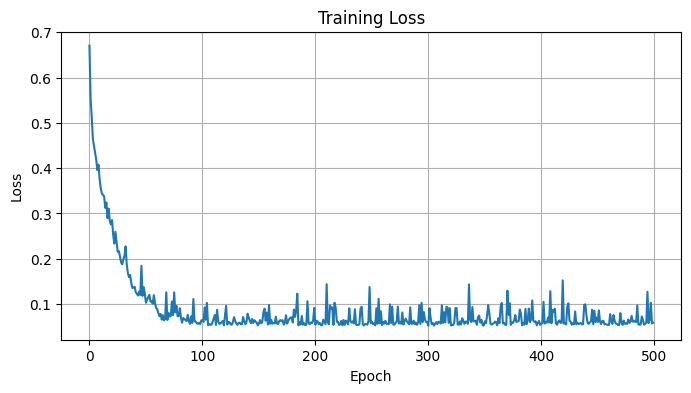

In [12]:

model, losses = train_model(model, dataloader, epochs=500, lr=1e-3)


Sample: cone_008


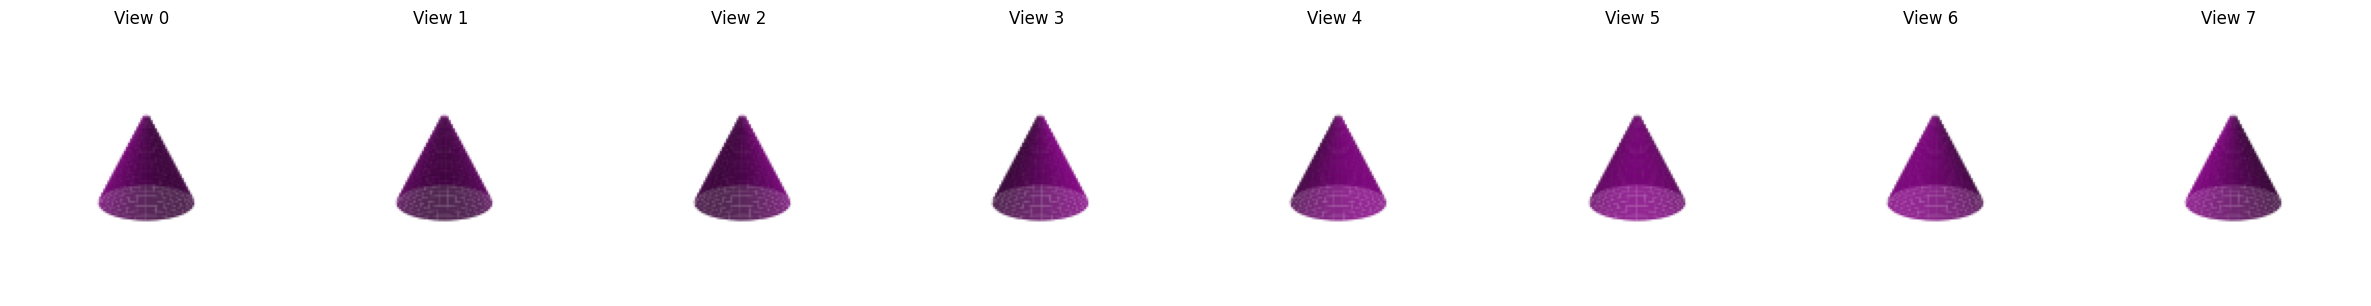

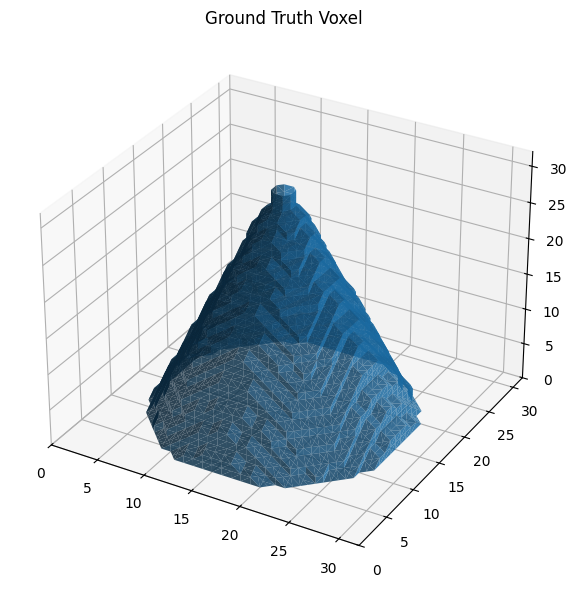

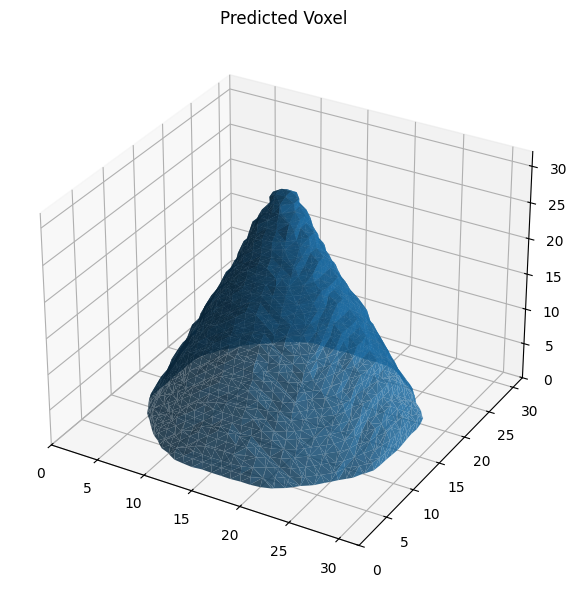

Saved predicted_voxel_sample.npy

Pipeline finished successfully


In [13]:

pred = visualize_prediction(model, dataset, sample_idx=1)
np.save("predicted_voxel_sample.npy", pred)
print("Saved predicted_voxel_sample.npy")
print("\nPipeline finished successfully")

Sample: cylinder_007


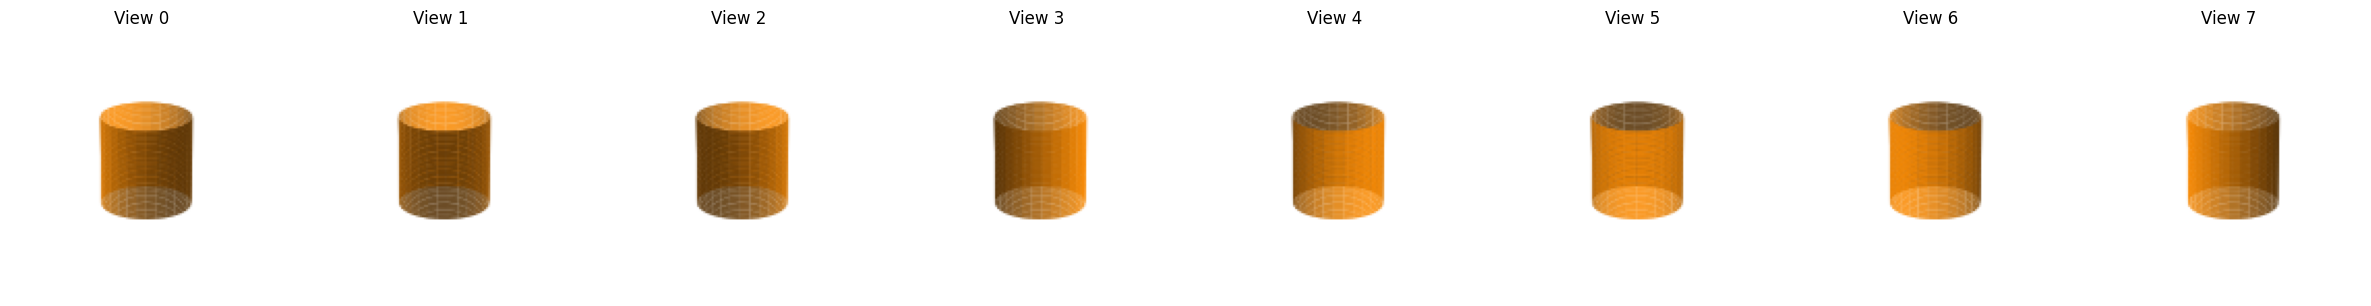

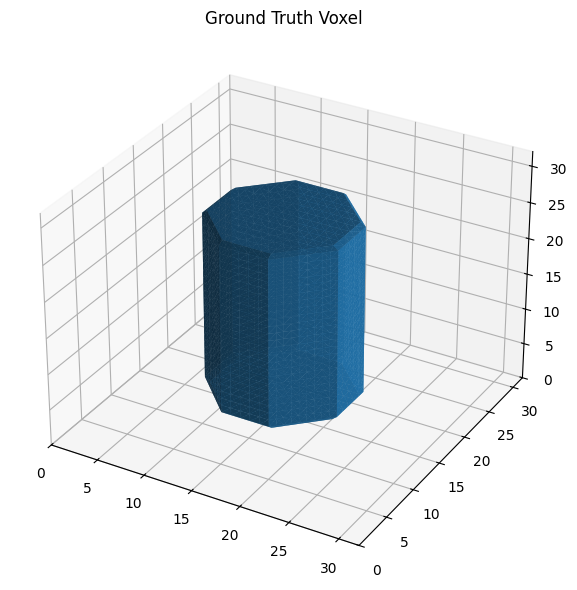

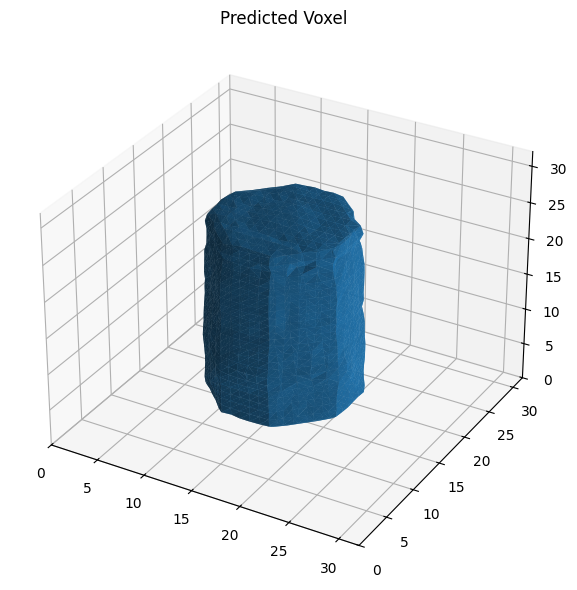

In [14]:
pred = visualize_prediction(model, dataset, sample_idx=9)

In [15]:
from skimage import measure
import open3d as o3d

def voxel_to_mesh_open3d(voxel, threshold=0.5):
    if voxel.ndim == 4:
        voxel = voxel[0]

    verts, faces, normals, _ = measure.marching_cubes(voxel, level=threshold)

    mesh = o3d.geometry.TriangleMesh()
    mesh.vertices = o3d.utility.Vector3dVector(verts)
    mesh.triangles = o3d.utility.Vector3iVector(faces)

    mesh.compute_vertex_normals()
    mesh.paint_uniform_color([0.7, 0.7, 0.9])

    o3d.io.write_triangle_mesh("model.ply", mesh)

In [16]:
voxel_to_mesh_open3d(pred)